# Linear Regression


In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

## 2.  線性迴歸訓練資料、測試資料

80%  training data, 20%  testing data ==> 先利用此來驗證各種模型(演算法)的好壞及調好到最佳參數
之後可以利用由這個80%的訓練資料所得的模型後,拿100%資料re-train模型以得到最佳模型 (此model會更佳fit data)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [18]:
x = np.linspace(0, 100, 1000)
y = 1.2*x + 0.8 + 0.6*np.random.randn(1000)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20) #random_state=20 看random模式是否固定
print(x_train)

[ 50.45045045  83.98398398  14.11411411  82.58258258  47.04704705
  92.69269269  17.31731732  11.71171171  85.58558559  30.83083083
  41.64164164  62.26226226  39.03903904   4.6046046   75.17517518
  53.25325325  23.72372372  61.36136136  45.64564565  35.13513514
  75.07507508  20.52052052  69.76976977  15.61561562  57.95795796
  73.87387387  44.94494494  49.84984985  65.66566567  74.17417417
  58.95895896  78.87887888  47.74774775  31.33133133  37.33733734
  60.56056056  84.88488488  28.52852853  88.28828829  35.83583584
  34.03403403  22.62262262  89.68968969  27.22722723  70.77077077
  46.74674675  17.21721722  83.58358358  60.16016016  17.11711712
  82.68268268  96.4964965   43.94394394  61.46146146  69.66966967
  12.81281281  64.56456456  37.63763764  52.65265265  35.43543544
  74.67467467  94.89489489   3.8038038    0.9009009   78.57857858
  74.37437437   2.6026026   76.87687688   8.90890891  70.47047047
   2.4024024   72.27227227  19.11911912  20.42042042  68.16816817
   4.40440

In [19]:
y

array([  0.92946773,   1.65725494,   0.56444028,   0.9285453 ,
         1.32774291,   1.2714458 ,   1.71435217,   2.13570643,
         1.24900412,   2.22433898,   1.85037112,   0.98522584,
         1.60473632,   2.29485275,   2.63382269,   2.57417895,
         3.0364935 ,   2.89459197,   3.42214386,   4.19117984,
         2.54697839,   2.98104499,   3.8103856 ,   3.79107993,
         3.8953256 ,   4.80883818,   3.95541256,   3.46243448,
         3.78953324,   3.45217   ,   5.41910755,   4.60243338,
         5.22707901,   3.76843236,   4.37738978,   4.16863475,
         5.21302958,   5.51476339,   5.31622401,   5.9780985 ,
         5.07326189,   5.13998893,   5.69049866,   5.8060478 ,
         6.27815438,   5.79219897,   6.44345151,   7.3729045 ,
         6.34076255,   7.3108348 ,   7.32239308,   7.37097787,
         6.49441133,   6.25601221,   6.34726217,   6.41119781,
         7.96214746,   6.93115622,   7.08099146,   8.38352715,
         8.15569735,   7.80011348,   7.46628401,   7.85

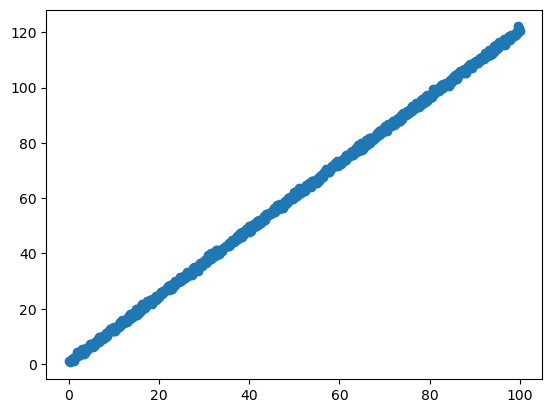

In [20]:
plt.scatter(x_train, y_train)

#### 用訓練資料來 fit 函數

記得現在我們只用 80% 的資料去訓練。

In [27]:
regr = LinearRegression()
X_train = x_train.reshape(-1,1)
regr.fit(X_train,y_train) #學習X_train和_y_train的關係，就會把關係記到regr中
print('Coefficients: ', regr.coef_)
print('interception: ', regr.intercept_)

Coefficients:  [1.20078829]
interception:  0.7734205507594609


In [28]:
Y_train = regr.predict(X_train) #用regr的函數，預測Y

In [29]:
mse = np.sum((Y_train-y_train)**2) / len(y_train)
print(mse)

0.36590570079509993


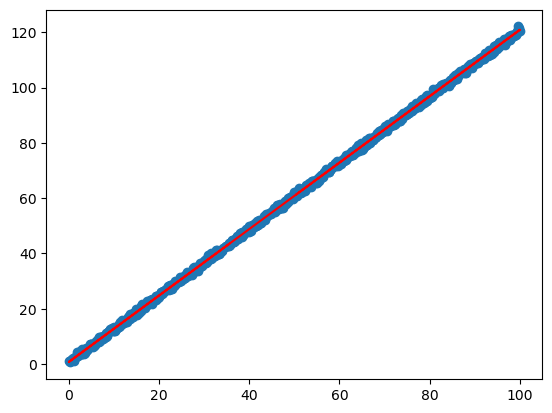

In [30]:
plt.scatter(x_train, y_train)
plt.plot(x_train, Y_train, 'r')

#### test with test data

In [31]:
X_test = x_test.reshape(-1,1)
Y_test = regr.predict(X_test)

print(Y_test)

[107.75055528  84.19154584  96.69224473  18.44267764 103.90418639
  54.38218694  76.97960417  16.03869708  98.37503112  53.42059472
  90.56209431  64.23850722  67.84447806  71.931245    60.75273542
  61.47392958   6.1823768    3.17740111  37.55432305   8.22576027
  75.05641972  96.33164764  13.39431847 105.34657473  42.60268222
  58.70935194  69.52726445  48.25203653  24.45262903  96.45184667
  22.40924555  33.10695903  63.15671597  62.07492472  47.29044431
 120.3714532    2.45620694 101.86080292  58.94975     73.73423042
  38.15531819  15.19730389  67.72427903 102.82239514 107.26975917
  32.74636194  96.5720457   40.19870167  73.25343431  60.27193931
 104.62538056  47.77124042  98.7356282    7.74496416  17.96188152
  24.81322611  78.18159445  62.55572083  49.21362875   4.61978944
 108.35155042  63.63751208  38.75631333  59.7911432   64.1183082
  26.4960125   88.03791473  64.35870625 117.72707459  33.22715805
  86.35512834  99.09622528  79.14318667  80.34517695  63.39711403
  59.550745

$$\widehat{y}=xw+b=w_{1}x_{1}+b$$

In [32]:
#Y=WX+b
W=regr.coef_
b=regr.intercept_
W*X_test+b


array([[107.75055528],
       [ 84.19154584],
       [ 96.69224473],
       [ 18.44267764],
       [103.90418639],
       [ 54.38218694],
       [ 76.97960417],
       [ 16.03869708],
       [ 98.37503112],
       [ 53.42059472],
       [ 90.56209431],
       [ 64.23850722],
       [ 67.84447806],
       [ 71.931245  ],
       [ 60.75273542],
       [ 61.47392958],
       [  6.1823768 ],
       [  3.17740111],
       [ 37.55432305],
       [  8.22576027],
       [ 75.05641972],
       [ 96.33164764],
       [ 13.39431847],
       [105.34657473],
       [ 42.60268222],
       [ 58.70935194],
       [ 69.52726445],
       [ 48.25203653],
       [ 24.45262903],
       [ 96.45184667],
       [ 22.40924555],
       [ 33.10695903],
       [ 63.15671597],
       [ 62.07492472],
       [ 47.29044431],
       [120.3714532 ],
       [  2.45620694],
       [101.86080292],
       [ 58.94975   ],
       [ 73.73423042],
       [ 38.15531819],
       [ 15.19730389],
       [ 67.72427903],
       [102

In [33]:
mse = np.sum((Y_test-y_test)**2) / len(y_test)
print(mse)

0.34624043200752225


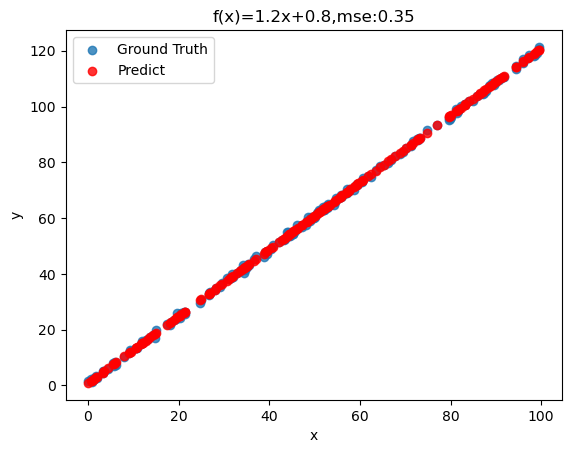

In [34]:
title='f(x)=1.2x+0.8'+',mse:'+str(round(mse,2))
plt.title(title)
plt.xlabel('x')
plt.ylabel('y')
#plt.grid(True)
plt.scatter(x_test, y_test,alpha=0.8,label='Ground Truth')
plt.scatter(x_test, Y_test, c='r', alpha=0.8,label='Predict')
plt.legend()